# Importação das Bibliotecas


In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
import cv2
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import os

import albumentations as A

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import  Input, Conv2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import Sequence
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import keras.layers as layers
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.metrics import roc_curve, auc

In [2]:
#os.environ["CUDA_VISIBLE_DEVICES"] = "0" 


#gpus = tf.config.list_physical_devices('GPU')
#if gpus:
#    try:
#        for gpu in gpus:
#            tf.config.experimental.set_memory_growth(gpu, True)
#    except RuntimeError as e:
#        print(e)

# Importação do Dataset

In [3]:
#Caminho das pastas

main_path = '256x256/'

train_dataframe = pd.read_csv(os.path.join(main_path, 'train_split.csv'))

val_dataframe = pd.read_csv(os.path.join(main_path, 'val_split.csv'))

In [4]:
train_dataframe

,filepath,label,patient_id
0,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.27275
1,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.14360
2,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.24989
3,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.16838
4,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.5783
...,...,...,...
10980,256x256/Slices_Saudaveis_PNG_256X256/1.2.826.0...,0,1.2.826.0.1.3680043.3389
10981,256x256/Slices_Saudaveis_PNG_256X256/1.2.826.0...,0,1.2.826.0.1.3680043.28637
10982,256x256/Slices_Saudaveis_PNG_256X256/1.2.826.0...,0,1.2.826.0.1.3680043.16206
10983,256x256/Slices_Saudaveis_PNG_256X256/1.2.826.0...,0,1.2.826.0.1.3680043.2152


In [5]:
val_dataframe

,filepath,label,patient_id
0,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.7147
1,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.13509
2,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.9940
3,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.25772
4,256x256/Slices_Fraturados_PNG_256x256/1.2.826....,1,1.2.826.0.1.3680043.11901
...,...,...,...
2444,256x256/Slices_Saudaveis_PNG_256X256/1.2.826.0...,0,1.2.826.0.1.3680043.31569
2445,256x256/Slices_Saudaveis_PNG_256X256/1.2.826.0...,0,1.2.826.0.1.3680043.6892
2446,256x256/Slices_Saudaveis_PNG_256X256/1.2.826.0...,0,1.2.826.0.1.3680043.12182
2447,256x256/Slices_Saudaveis_PNG_256X256/1.2.826.0...,0,1.2.826.0.1.3680043.5949


In [6]:
intersecao = set(train_dataframe['patient_id']).intersection(set(val_dataframe['patient_id']))
print(f"Pacientes em comum: {len(intersecao)}")

Pacientes em comum: 0


# Pesos das Classes

In [7]:
Num_classes = 2

Num_saudaveis = train_dataframe['label'].value_counts()[0] + val_dataframe['label'].value_counts()[0]

#print(Num_saudaveis)

Num_fraturados = train_dataframe['label'].value_counts()[1] + val_dataframe['label'].value_counts()[1]

#print(Num_fraturados)

weight_saudaveis = (Num_saudaveis + Num_fraturados) / (Num_classes * Num_saudaveis)

print(f"Pesos dos slices saudáveis: {round(weight_saudaveis, 5)} \n")

weight_fraturados = (Num_saudaveis + Num_fraturados) / (Num_classes * Num_fraturados)

print(f"Pesos dos slices fraturados: {round(weight_fraturados, 5)} \n")

Pesos dos slices saudáveis: 1.0 

Pesos dos slices fraturados: 1.0 



# Carregamento e Normalização das Imagens

In [8]:
def load_image(filepath):
    
    try:
        
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        
        if img is None: 
            return None
        
    
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return img_rgb
    
    except Exception as e:
        print(f"Erro ao carregar {filepath}: {e}")
        return None

# Data Augmentation

In [9]:
train_DataAugmentation = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.Rotate(limit = (-20,20), interpolation = cv2.INTER_LINEAR, border_mode = cv2.BORDER_CONSTANT, fill = 0, p = 0.6), #random rotation

    A.RandomScale(scale_limit = (-0.12,0.12), interpolation = cv2.INTER_LINEAR, mask_interpolation = cv2.INTER_LINEAR, p = 0.75), #zoom

    A.ElasticTransform(alpha=350.0, sigma=20, interpolation=cv2.INTER_CUBIC, p=0.5, border_mode=cv2.BORDER_CONSTANT, fill = 0),

    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.14, brightness_by_max = False, ensure_safe_range = False, p=0.2),

    A.GaussianBlur(sigma_limit=(0.2, 0.7), blur_limit = (3,3), p=0.4),

    A.PadIfNeeded(min_height=256, min_width=256, border_mode=cv2.BORDER_CONSTANT, fill=0),
    A.CenterCrop(height=256, width=256)
])

#train_DataAugmentation = ImageDataGenerator(
#    rotation_range = 45,
#    horizontal_flip = True    
#)

#Ajustar o data augmentation pra deixar conforme as referências: random horizontal flip, 
#random rotation, Gaussian blur, Translation, Zoomed-in/scaling, Elastic transformation,
#Rotation e Contrast/brightness enhancement.

#Cervical Spine Fracture Detection and Classification Using Two-Stage Deep Learning Methodology
#Improving Vertebral Fracture Detection in C-Spine CT Images Using Bayesian Probability-Based Ensemble Learning 

# Data Generators

In [10]:
class_weights = {
    0: weight_saudaveis,
    1: weight_fraturados
}

In [11]:
#https://mahmoudyusof.github.io/blog/
#https://medium.com/@lucas.lvtj/explorando-a-classifica%C3%A7%C3%A3o-de-imagens-com-resnet50-19ee263393e3

class DataGenerator(Sequence):
    
    def __init__(self, dataframe, batch_size = 4, shuffle = False, augmentation = None, **kwargs):
        super().__init__(**kwargs)
        self.df = dataframe
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.num_classes = 2
        self.augmentation = augmentation
        self.on_epoch_end()
        
    def __getitem__(self, idx):
        indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        df_batch = self.df.iloc[indices]
        X, y = self.__data_generation(df_batch)
        return X, y
        
    
    def on_epoch_end(self):
        self.indices = np.arange(len(self.df))
        if self.shuffle == True:
            np.random.shuffle(self.indices)
    
    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))
    
       
    def __data_generation(self, df_batch):
        
        current_batch_size = len(df_batch)
        X = np.zeros((self.batch_size, 256, 256, 3), dtype = np.float32)
        y = np.zeros((self.batch_size), dtype = np.uint8)
        
        for i, (idx, row) in enumerate(df_batch.iterrows()):
            
           image = load_image(row['filepath'])
           
           if image is not None:
                          
               if self.augmentation is not None:
                                                         
                   augmented = self.augmentation(image = image)
                   image = augmented['image']
                              
               image_final = preprocess_input(image)
                
               X[i] = image_final
               y[i] = row['label']
                
           else: 
               
               print(f"erro{row['filepath']}")
               y[i] = row['label']        
             
        y_one_hot = tf.keras.utils.to_categorical(y, num_classes = self.num_classes)
        
        return X, y_one_hot  

In [12]:
Batch_size = 16

train_generator = DataGenerator(train_dataframe, batch_size= Batch_size, shuffle = True, augmentation = train_DataAugmentation)

val_generator = DataGenerator(val_dataframe, batch_size= Batch_size, shuffle = False, augmentation = None)

# Arquitetura DenseNet121

In [13]:
def model_DenseNet121_Transfer(input_shape=(256, 256, 3), num_classes=2, trainable_base=False):

    inputs = Input(shape=input_shape)
    
    densenet121_base = DenseNet121(include_top=False, weights='imagenet', input_tensor=inputs)

    densenet121_base.trainable = trainable_base

    x = layers.GlobalMaxPooling2D()(densenet121_base.output)
    
    #x = layers.GlobalAveragePooling2D()(densenet121_base.output)

    x = Dense(512, activation='relu')(x) #kernel_regularizer=tf.keras.regularizers.l2(0.0001)
    x = Dropout(0.6)(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    predictions = Dense(num_classes, activation=None)(x)

    model = Model(inputs=inputs, outputs=predictions)

    return model, densenet121_base

In [14]:
model, densenet121_base = model_DenseNet121_Transfer(trainable_base=False)

model.compile(optimizer=AdamW(learning_rate= 1e-4,
                              weight_decay = 1e-3), 
              loss=CategoricalCrossentropy(from_logits = True), 
              metrics=['accuracy'])

print("Model fit 1 - Pesos congelados")
model.fit(train_generator, epochs=10, validation_data=val_generator, class_weight=class_weights)

#Alterar learning_rate e/ou número de épocas.

I0000 00:00:1769970375.666960 1576071 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6178 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1769970375.670035 1576071 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 4424 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6


Model fit 1 - Pesos congelados
Epoch 1/10


2026-02-01 18:26:37.091677: I external/local_xla/xla/service/service.cc:163] XLA service 0x7749a4002670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-01 18:26:37.091704: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2026-02-01 18:26:37.091713: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-02-01 18:26:37.806895: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-01 18:26:42.222730: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


  1/686 ━━━━━━━━━━━━━━━━━━━━ 8:12:21 43s/step - accuracy: 0.5625 - loss: 3.3520

I0000 00:00:1769970423.973114 1577880 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


686/686 ━━━━━━━━━━━━━━━━━━━━ 220s 258ms/step - accuracy: 0.5377 - loss: 1.1760 - val_accuracy: 0.5976 - val_loss: 0.6634
Epoch 2/10
686/686 ━━━━━━━━━━━━━━━━━━━━ 160s 233ms/step - accuracy: 0.5958 - loss: 0.7172 - val_accuracy: 0.6609 - val_loss: 0.6285
Epoch 3/10
686/686 ━━━━━━━━━━━━━━━━━━━━ 159s 231ms/step - accuracy: 0.6358 - loss: 0.6469 - val_accuracy: 0.6777 - val_loss: 0.6044
Epoch 4/10
686/686 ━━━━━━━━━━━━━━━━━━━━ 160s 233ms/step - accuracy: 0.6705 - loss: 0.6066 - val_accuracy: 0.6667 - val_loss: 0.5940
Epoch 5/10
686/686 ━━━━━━━━━━━━━━━━━━━━ 162s 236ms/step - accuracy: 0.6825 - loss: 0.5928 - val_accuracy: 0.6797 - val_loss: 0.5959
Epoch 6/10
686/686 ━━━━━━━━━━━━━━━━━━━━ 158s 230ms/step - accuracy: 0.7095 - loss: 0.5609 - val_accuracy: 0.6834 - val_loss: 0.5759
Epoch 7/10
686/686 ━━━━━━━━━━━━━━━━━━━━ 160s 233ms/step - accuracy: 0.7120 - loss: 0.5500 - val_accuracy: 0.6900 - val_loss: 0.5737
Epoch 8/10
686/686 ━━━━━━━━━━━━━━━━━━━━ 159s 232ms/step - accuracy: 0.7338 - loss: 0.53

In [16]:
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 12, restore_best_weights = True)

reduce_plateau = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 5, min_lr = 1e-7, verbose = 1)

In [17]:
densenet121_base.trainable = True

model.compile(optimizer=AdamW(learning_rate= 1e-6,
                              weight_decay = 1e-3),
              loss=CategoricalCrossentropy(from_logits = True),
              metrics=['accuracy'],
              jit_compile = False)

#Alterar learning_rate e/ou número de épocas.

history = model.fit(train_generator,
                    epochs=75,
                    validation_data=val_generator,
                    callbacks=[early_stopping, reduce_plateau],
                    class_weight=class_weights)

Epoch 1/75
686/686 ━━━━━━━━━━━━━━━━━━━━ 392s 426ms/step - accuracy: 0.6462 - loss: 0.7316 - val_accuracy: 0.6777 - val_loss: 0.6032 - learning_rate: 1.0000e-06
Epoch 2/75
686/686 ━━━━━━━━━━━━━━━━━━━━ 286s 417ms/step - accuracy: 0.6937 - loss: 0.6187 - val_accuracy: 0.6998 - val_loss: 0.5773 - learning_rate: 1.0000e-06
Epoch 3/75
686/686 ━━━━━━━━━━━━━━━━━━━━ 286s 417ms/step - accuracy: 0.7132 - loss: 0.5703 - val_accuracy: 0.7063 - val_loss: 0.5624 - learning_rate: 1.0000e-06
Epoch 4/75
686/686 ━━━━━━━━━━━━━━━━━━━━ 286s 417ms/step - accuracy: 0.7381 - loss: 0.5401 - val_accuracy: 0.7141 - val_loss: 0.5490 - learning_rate: 1.0000e-06
Epoch 5/75
686/686 ━━━━━━━━━━━━━━━━━━━━ 286s 417ms/step - accuracy: 0.7445 - loss: 0.5221 - val_accuracy: 0.7210 - val_loss: 0.5398 - learning_rate: 1.0000e-06
Epoch 6/75
686/686 ━━━━━━━━━━━━━━━━━━━━ 286s 417ms/step - accuracy: 0.7596 - loss: 0.5048 - val_accuracy: 0.7283 - val_loss: 0.5328 - learning_rate: 1.0000e-06
Epoch 7/75
686/686 ━━━━━━━━━━━━━━━━━━━━ 

# Matriz de Confusão e Gráficos

153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step


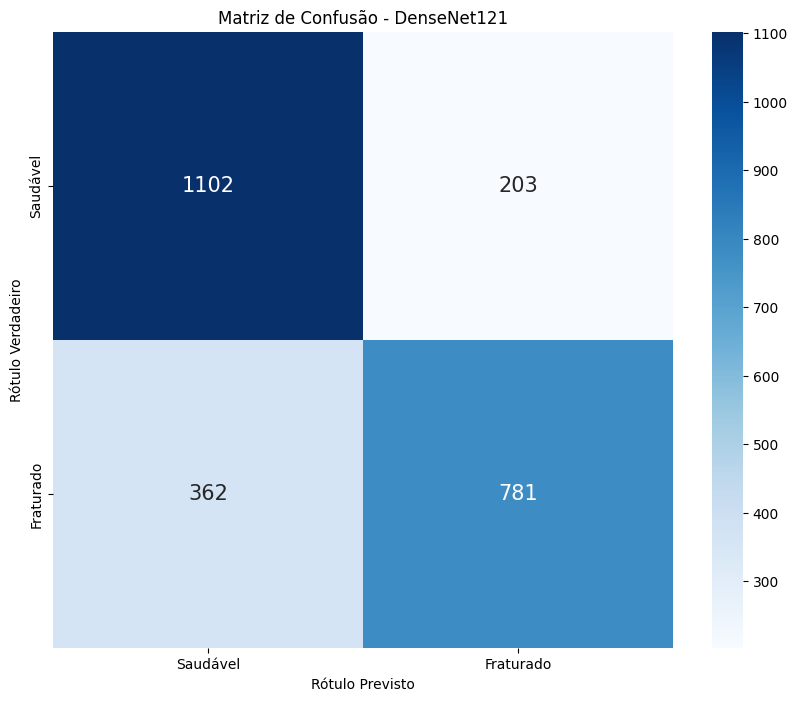

Acurácia:0.7692 
 Recall: 0.68329 
 Precisão: 0.7937 
 F1_Score: 0.73437 
 Especificidade: 0.84444 

Relatório
              precision    recall  f1-score   support

    Saudável       0.75      0.84      0.80      1305
   Fraturado       0.79      0.68      0.73      1143

    accuracy                           0.77      2448
   macro avg       0.77      0.76      0.77      2448
weighted avg       0.77      0.77      0.77      2448



In [23]:
predict_logits = model.predict(val_generator)

predict_res = tf.nn.softmax(predict_logits).numpy()

predict_labels = np.argmax(predict_res, axis = 1)

y_true = []

for i in range(len(val_generator)):
    
    _, batch_y_one_hot = val_generator[i]
    batch_y_labels = np.argmax(batch_y_one_hot, axis = 1)
    y_true.extend(batch_y_labels)

y_true = np.array(y_true)

acc = accuracy_score(y_true , predict_labels)

recall = recall_score(y_true, predict_labels)

precision = precision_score(y_true, predict_labels)

f1 = f1_score(y_true, predict_labels)


cm = confusion_matrix(y_true, predict_labels)
cm_normalizada = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]

labels = [f"{v}\n({p:.2%})" for v, p in zip(cm.flatten(), cm_normalizada.flatten())]
labels = np.asarray(labels).reshape(cm.shape)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot = True, fmt ='d', cmap = 'Blues',
            xticklabels = ['Saudável', 'Fraturado'],
            yticklabels = ['Saudável', 'Fraturado'],
            annot_kws={"size":15})

plt.title('Matriz de Confusão - DenseNet121')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Previsto')
plt.show()


print(f"Acurácia:{round(acc,5)} \n Recall: {round(recall,5)} \n Precisão: {round(precision,5)} \n F1_Score: {round(f1,5)} \n Especificidade: {round(specificity,5)} \n")


print('Relatório')
print(classification_report(y_true, predict_labels, target_names = ['Saudável','Fraturado']))

In [ ]:
def plot_roc_curve(y_true, y_probs):
    
    fpr, tpr, thresholds = roc_curve(y_true, y_probs[:, 1])
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Linha de base (aleatória)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.title('Curva ROC - Detecção de Fraturas - DenseNet121')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

In [1]:
def plot_learning_curves(history):
    
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Gráfico de Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, val_acc, label='Validação')
    plt.title('Acurácia de Treino e Validação - DenseNet121')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend(loc='lower right')
    plt.grid(alpha = 0.3)

    # Gráfico de Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Treino')
    plt.plot(epochs_range, val_loss, label='Validação')
    plt.title('Treino e Validação - Loss - DenseNet121')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(alpha = 0.3)
    
    plt.tight_layout()
    plt.show()

In [2]:
plot_learning_curves(history)

NameError: name 'history' is not defined

153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step


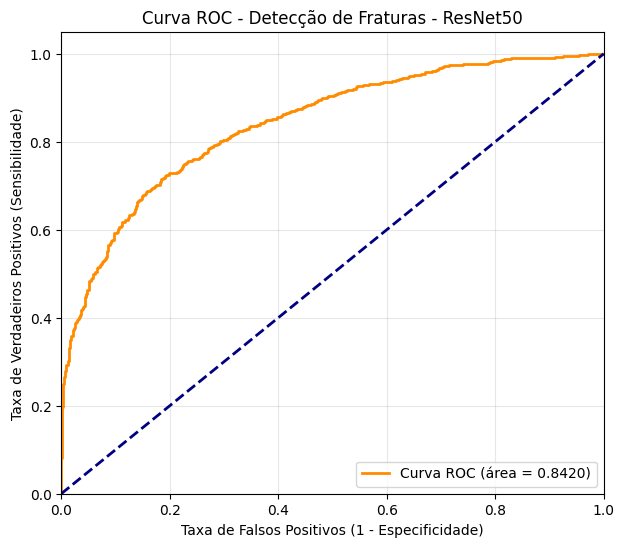

In [26]:
predict_logits = model.predict(val_generator)
predict_probs = tf.nn.softmax(predict_logits).numpy()

plot_roc_curve(y_true, predict_res)